In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/processed/monthly_vehicle_demand.csv")

df["month"] = pd.to_datetime(df["month"])

print("Shape:", df.shape)
df.head()

Shape: (23650, 5)


,month,state,vehicle_type,registrations,vehicle_group
0,2019-01-01,Andaman And Nicobar Islands,Heavy Goods Vehicle,9.0,Goods Vehicle
1,2019-01-01,Andaman And Nicobar Islands,Heavy Passenger Vehicle,1.0,Passenger Transport
2,2019-01-01,Andaman And Nicobar Islands,Light Goods Vehicle,21.0,Goods Vehicle
3,2019-01-01,Andaman And Nicobar Islands,Light Motor Vehicle,161.0,Passenger Vehicle
4,2019-01-01,Andaman And Nicobar Islands,Light Passenger Vehicle,27.0,Passenger Vehicle


In [3]:
overall_demand = (
    df.groupby("month")["registrations"]
      .sum()
      .reset_index()
)

overall_demand.head()

,month,registrations
0,2019-01-01,2274333.0
1,2019-02-01,1947762.0
2,2019-03-01,2119354.0
3,2019-04-01,2011386.0
4,2019-05-01,2101770.0


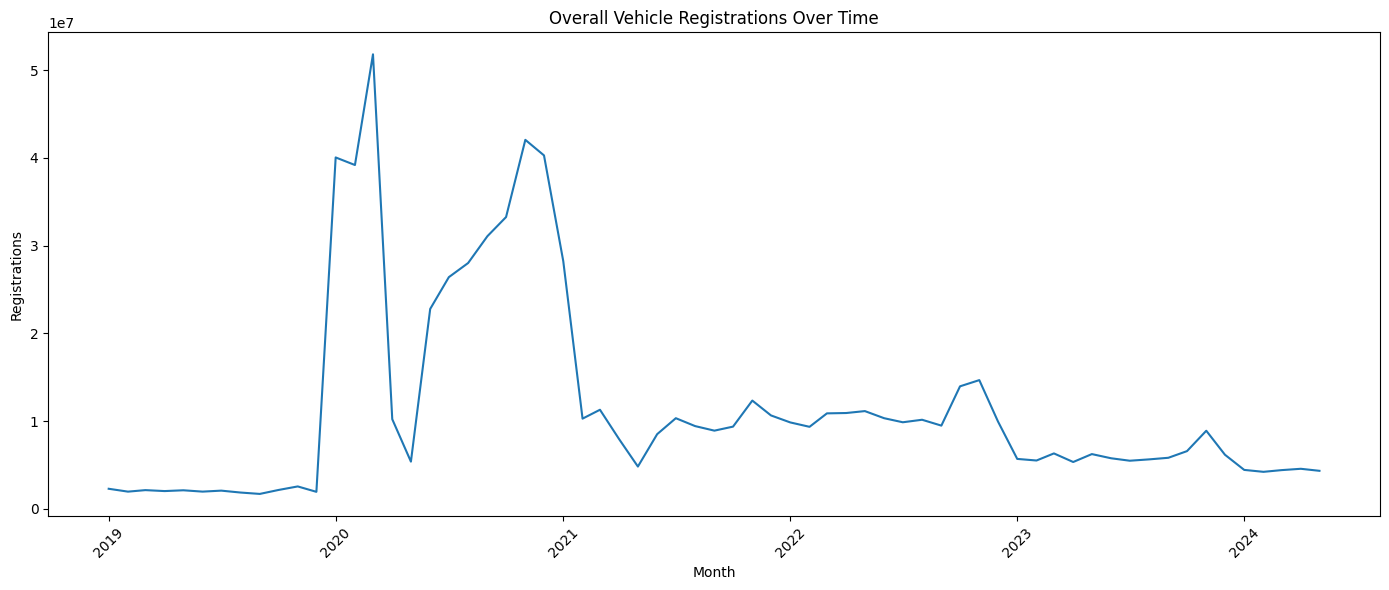

In [4]:
plt.figure(figsize=(14, 6))

plt.plot(
    overall_demand["month"],
    overall_demand["registrations"]
)

plt.title("Overall Vehicle Registrations Over Time")
plt.xlabel("Month")
plt.ylabel("Registrations")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
group_demand = (
    df.groupby("vehicle_group")["registrations"]
      .sum()
      .sort_values(ascending=False)
)

group_demand

vehicle_group
Two Wheeler            564629126.0
Passenger Vehicle      138538848.0
Goods Vehicle           27494404.0
Three Wheeler           20151302.0
Passenger Transport      1081049.0
Other Motor Vehicle       757219.0
Name: registrations, dtype: float64

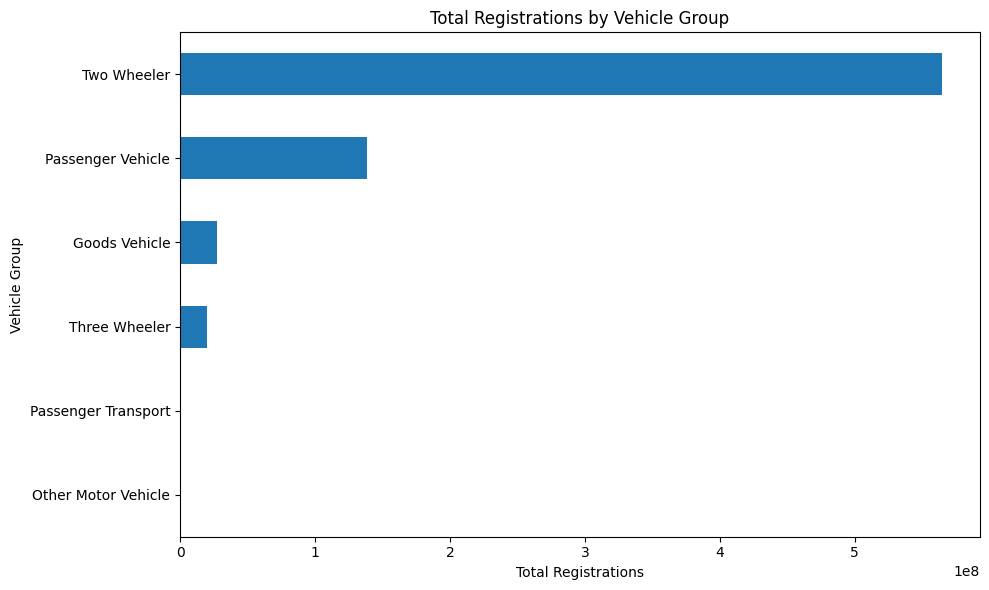

In [6]:
plt.figure(figsize=(10, 6))

group_demand.sort_values().plot(kind="barh")

plt.title("Total Registrations by Vehicle Group")
plt.xlabel("Total Registrations")
plt.ylabel("Vehicle Group")

plt.tight_layout()
plt.show()


In [7]:
group_monthly = (
    df.groupby(["month", "vehicle_group"])["registrations"]
      .sum()
      .reset_index()
)

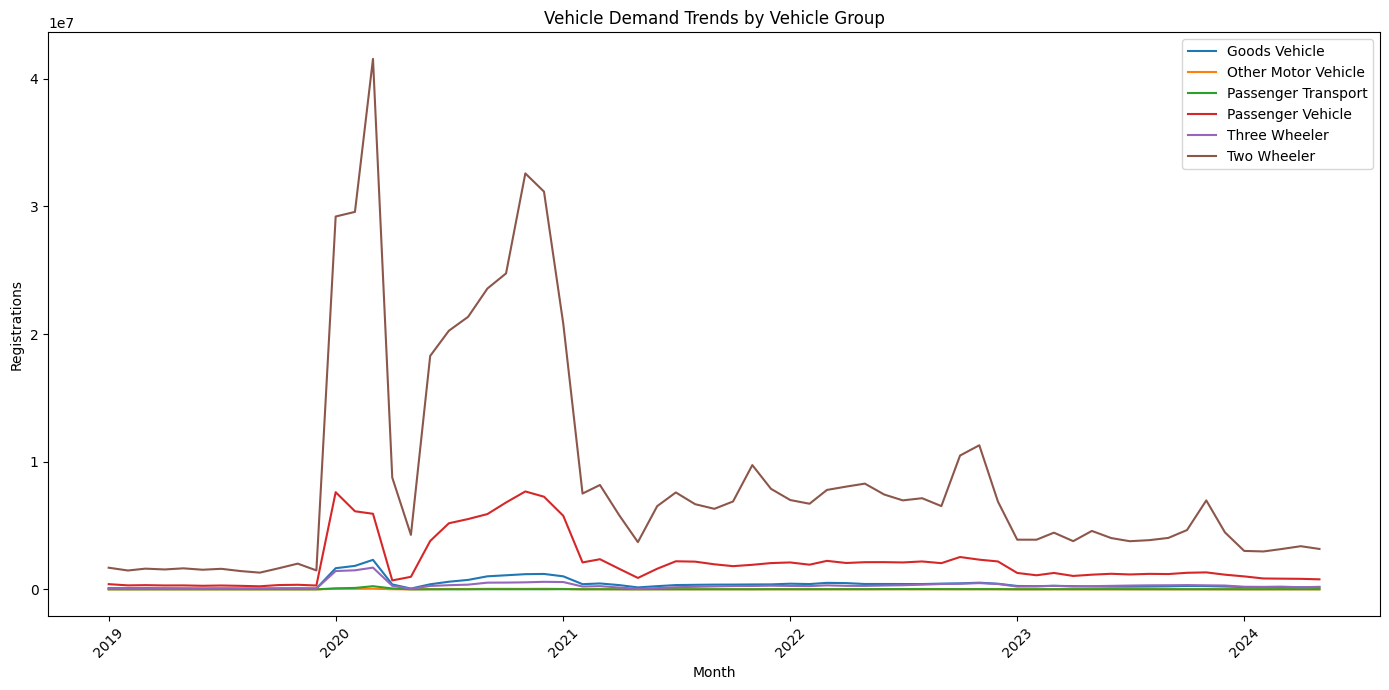

In [8]:
plt.figure(figsize=(14, 7))

for group in group_monthly["vehicle_group"].unique():

    temp = group_monthly[
        group_monthly["vehicle_group"] == group
    ]

    plt.plot(
        temp["month"],
        temp["registrations"],
        label=group
    )

plt.title("Vehicle Demand Trends by Vehicle Group")
plt.xlabel("Month")
plt.ylabel("Registrations")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
state_demand = (
    df.groupby("state")["registrations"]
      .sum()
      .sort_values(ascending=False)
)

state_demand.head(10)

state
Andhra Pradesh       157498828.0
Tamil Nadu           139204888.0
Rajasthan             87580324.0
Arunachal Pradesh     82965617.0
Kerala                63065362.0
Punjab                40880551.0
Madhya Pradesh        26862519.0
Bihar                 24854997.0
West Bengal           24159116.0
Delhi                 19493803.0
Name: registrations, dtype: float64

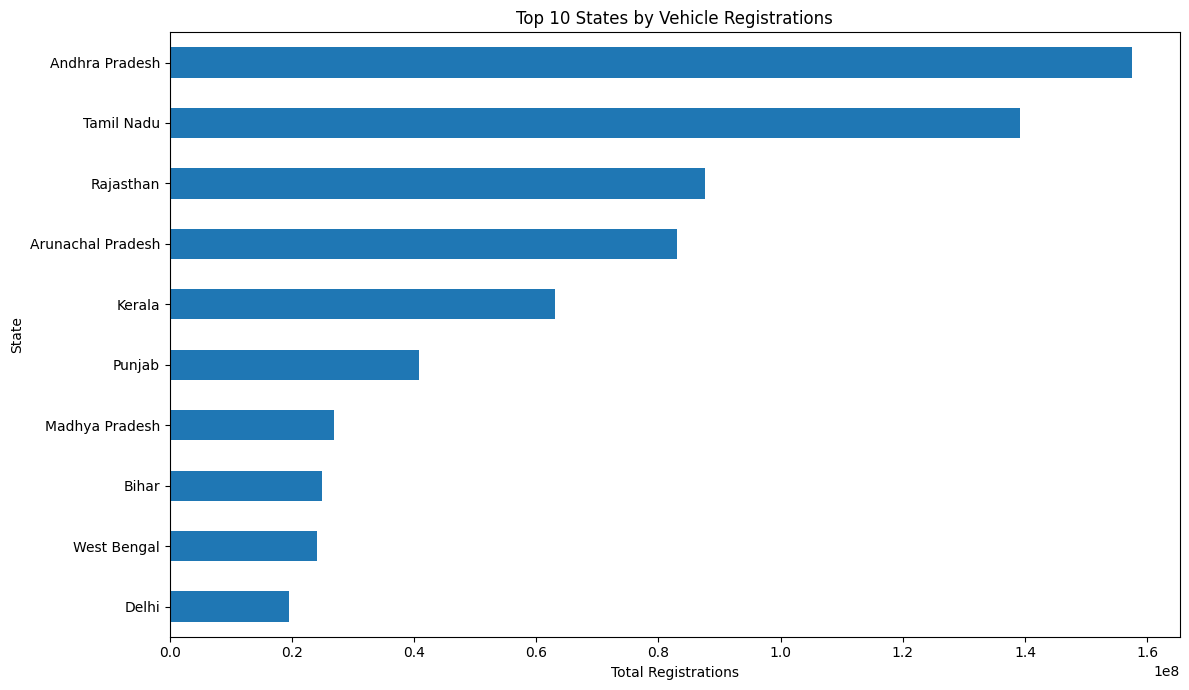

In [10]:
plt.figure(figsize=(12, 7))

state_demand.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 States by Vehicle Registrations")
plt.xlabel("Total Registrations")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [11]:
state_group = pd.pivot_table(
    df,
    values="registrations",
    index="state",
    columns="vehicle_group",
    aggfunc="sum",
    fill_value=0
)

state_group.head()

vehicle_group,Goods Vehicle,Other Motor Vehicle,Passenger Transport,Passenger Vehicle,Three Wheeler,Two Wheeler
state,,,,,,
Andaman And Nicobar Islands,1471.0,38.0,103.0,9383.0,1399.0,27369.0
Andhra Pradesh,5807474.0,163918.0,186888.0,29535423.0,3902962.0,117902163.0
Arunachal Pradesh,3170623.0,79346.0,121668.0,16024800.0,2595757.0,60973423.0
Assam,180280.0,826.0,3534.0,431127.0,210584.0,2002789.0
Bihar,920037.0,25315.0,35246.0,3632039.0,794698.0,19447662.0


In [12]:
top_states = state_demand.head(10).index

state_group_top = state_group.loc[top_states]

state_group_top

vehicle_group,Goods Vehicle,Other Motor Vehicle,Passenger Transport,Passenger Vehicle,Three Wheeler,Two Wheeler
state,,,,,,
Andhra Pradesh,5807474.0,163918.0,186888.0,29535423.0,3902962.0,117902163.0
Tamil Nadu,4728400.0,151244.0,215239.0,23594441.0,3013440.0,107502124.0
Rajasthan,3490484.0,73391.0,132883.0,17544074.0,2964313.0,63375179.0
Arunachal Pradesh,3170623.0,79346.0,121668.0,16024800.0,2595757.0,60973423.0
Kerala,2341303.0,65137.0,75660.0,12341392.0,1612110.0,46629760.0
Punjab,1368327.0,42196.0,62850.0,7175872.0,888494.0,31342812.0
Madhya Pradesh,800147.0,33875.0,35469.0,4706592.0,565339.0,20721097.0
Bihar,920037.0,25315.0,35246.0,3632039.0,794698.0,19447662.0
West Bengal,839662.0,22356.0,33658.0,3778125.0,496086.0,18989229.0


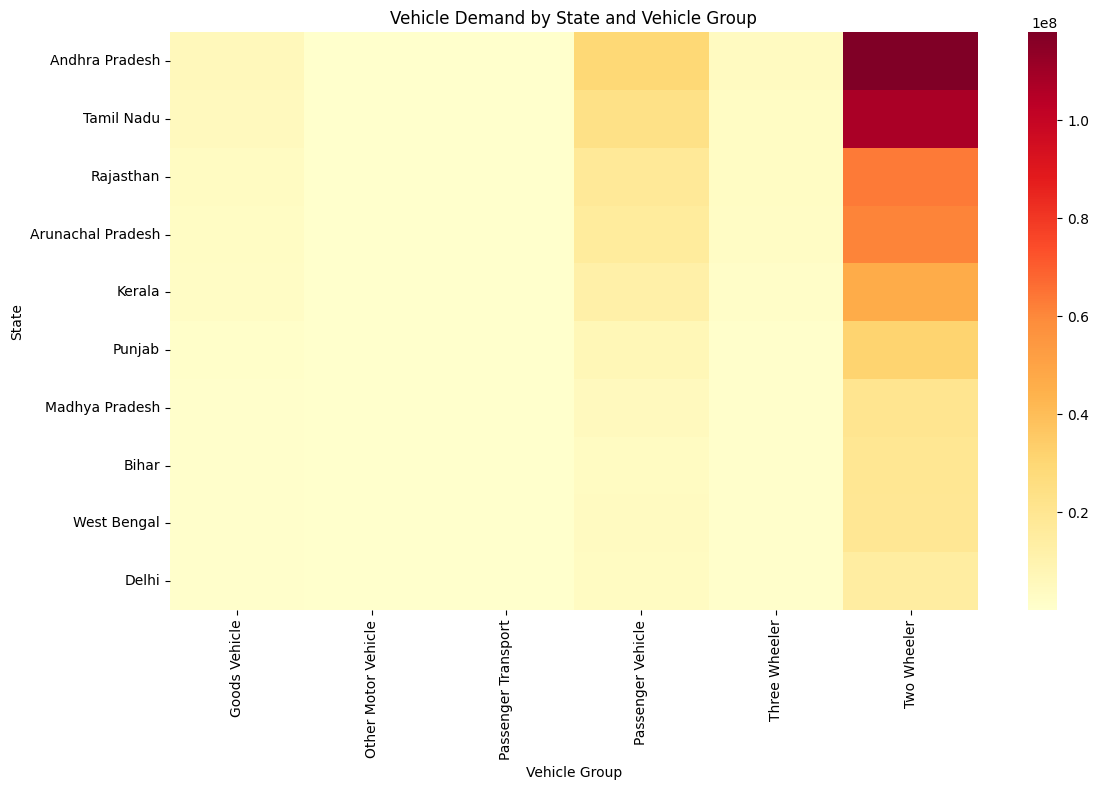

In [13]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    state_group_top,
    annot=False,
    cmap="YlOrRd"
)

plt.title("Vehicle Demand by State and Vehicle Group")
plt.xlabel("Vehicle Group")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [14]:
df["month_number"] = df["month"].dt.month

In [15]:
monthly_seasonality = (
    df.groupby("month_number")["registrations"]
      .mean()
)

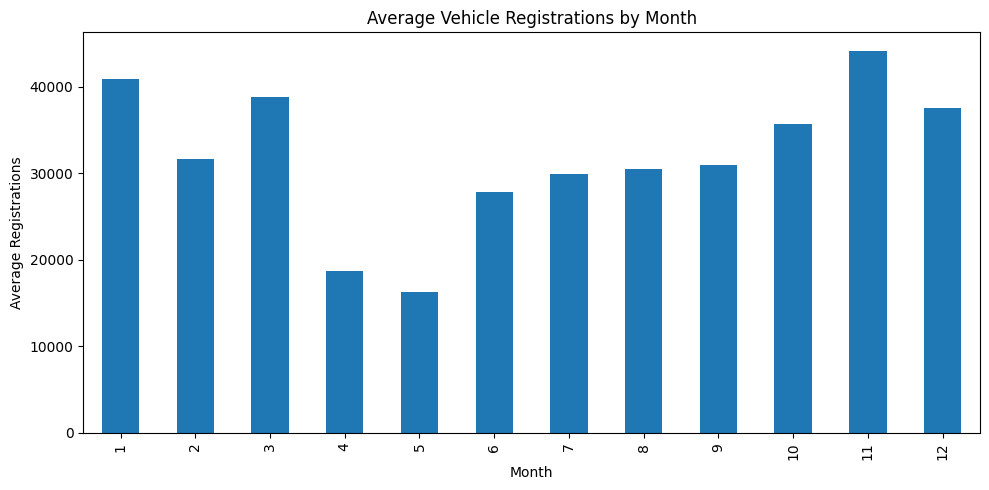

In [16]:
plt.figure(figsize=(10, 5))

monthly_seasonality.plot(kind="bar")

plt.title("Average Vehicle Registrations by Month")
plt.xlabel("Month")
plt.ylabel("Average Registrations")

plt.tight_layout()
plt.show()

In [17]:
state_group_monthly = (
    df.groupby(
        ["state", "vehicle_group", "month"]
    )["registrations"]
    .sum()
    .reset_index()
)

In [18]:
state_group_monthly["rolling_mean"] = (
    state_group_monthly
    .groupby(["state", "vehicle_group"])["registrations"]
    .transform(
        lambda x: x.rolling(6, min_periods=3).mean()
    )
)

In [19]:
state_group_monthly["demand_ratio"] = (
    state_group_monthly["registrations"] /
    state_group_monthly["rolling_mean"]
)

In [20]:
spikes = state_group_monthly[
    state_group_monthly["demand_ratio"] > 1.5
].sort_values(
    "demand_ratio",
    ascending=False
)

spikes.head(20)

,state,vehicle_group,month,registrations,rolling_mean,demand_ratio
4323,Himachal Pradesh,Three Wheeler,2020-01-01,71714.0,11973.166667,5.989560
957,Arunachal Pradesh,Three Wheeler,2020-01-01,71725.0,12016.000000,5.969125
1022,Arunachal Pradesh,Two Wheeler,2020-01-01,1460312.0,245237.500000,5.954685
892,Arunachal Pradesh,Passenger Vehicle,2020-01-01,380528.0,63986.000000,5.947051
697,Arunachal Pradesh,Goods Vehicle,2020-01-01,82981.0,13957.333333,5.945333
762,Arunachal Pradesh,Other Motor Vehicle,2020-01-01,2066.0,349.666667,5.908484
7834,Mizoram,Passenger Transport,2021-05-01,487.0,82.500000,5.903030
7871,Mizoram,Passenger Vehicle,2021-05-01,111140.0,18883.833333,5.885458
372,Andhra Pradesh,Other Motor Vehicle,2020-01-01,6196.0,1052.833333,5.885072
4388,Himachal Pradesh,Two Wheeler,2020-01-01,1461845.0,249361.166667,5.862360


In [21]:
print("===== DATASET =====")
print("Shape:", df.shape)

print("\n===== DATE RANGE =====")
print("Start:", df["month"].min())
print("End:", df["month"].max())

print("\n===== VEHICLE GROUPS =====")
print(group_demand)

print("\n===== TOP 10 STATES =====")
print(state_demand.head(10))

print("\n===== TOP 20 POTENTIAL SPIKES =====")
print(
    spikes[
        ["state", "vehicle_group", "month",
         "registrations", "rolling_mean", "demand_ratio"]
    ].head(20)
)

===== DATASET =====
Shape: (23650, 6)

===== DATE RANGE =====
Start: 2019-01-01 00:00:00
End: 2024-05-01 00:00:00

===== VEHICLE GROUPS =====
vehicle_group
Two Wheeler            564629126.0
Passenger Vehicle      138538848.0
Goods Vehicle           27494404.0
Three Wheeler           20151302.0
Passenger Transport      1081049.0
Other Motor Vehicle       757219.0
Name: registrations, dtype: float64

===== TOP 10 STATES =====
state
Andhra Pradesh       157498828.0
Tamil Nadu           139204888.0
Rajasthan             87580324.0
Arunachal Pradesh     82965617.0
Kerala                63065362.0
Punjab                40880551.0
Madhya Pradesh        26862519.0
Bihar                 24854997.0
West Bengal           24159116.0
Delhi                 19493803.0
Name: registrations, dtype: float64

===== TOP 20 POTENTIAL SPIKES =====
                   state        vehicle_group      month  registrations  \
4323    Himachal Pradesh        Three Wheeler 2020-01-01        71714.0   
957    Aruna